<a href="https://colab.research.google.com/github/hir0ki-eng/HAR-Portfolio/blob/main/HAR_LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving human+activity+recognition+using+smartphones.zip to human+activity+recognition+using+smartphones.zip


In [13]:
import zipfile

#1つ目のZIPを展開
with zipfile.ZipFile(
    "/content/human+activity+recognition+using+smartphones.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("/content/har_data")

# 中に入っている2つ目のZIPを展開
with zipfile.ZipFile(
    "/content/har_data/UCI HAR Dataset.zip",
    "r"
) as zip_ref:
    zip_ref.extractall("/content/har_data")

data_path = "/content/har_data/UCI HAR Dataset"

import pandas as pd

X_train = pd.read_csv(
    f"{data_path}/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    f"{data_path}/train/y_train.txt",
    sep=r"\s+",
    header=None
)

X_test = pd.read_csv(
    f"{data_path}/test/X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    f"{data_path}/test/y_test.txt",
    sep=r"\s+",
    header=None
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (7352, 561)
y_train: (7352, 1)
X_test : (2947, 561)
y_test : (2947, 1)


In [15]:
activity_labels = pd.read_csv(
    f"{data_path}/activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["label", "activity"]
)


print(activity_labels)

   label            activity
0      1             WALKING
1      2    WALKING_UPSTAIRS
2      3  WALKING_DOWNSTAIRS
3      4             SITTING
4      5            STANDING
5      6              LAYING


In [16]:
print(y_train.head(10))
print(y_train[0].value_counts().sort_index())

   0
0  5
1  5
2  5
3  5
4  5
5  5
6  5
7  5
8  5
9  5
0
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64


In [17]:
features = pd.read_csv(
    f"{data_path}/features.txt",
    sep=r"\s+",
    header=None,
    names=["number", "feature"]
)

print(features.head(20))

    number              feature
0        1    tBodyAcc-mean()-X
1        2    tBodyAcc-mean()-Y
2        3    tBodyAcc-mean()-Z
3        4     tBodyAcc-std()-X
4        5     tBodyAcc-std()-Y
5        6     tBodyAcc-std()-Z
6        7     tBodyAcc-mad()-X
7        8     tBodyAcc-mad()-Y
8        9     tBodyAcc-mad()-Z
9       10     tBodyAcc-max()-X
10      11     tBodyAcc-max()-Y
11      12     tBodyAcc-max()-Z
12      13     tBodyAcc-min()-X
13      14     tBodyAcc-min()-Y
14      15     tBodyAcc-min()-Z
15      16       tBodyAcc-sma()
16      17  tBodyAcc-energy()-X
17      18  tBodyAcc-energy()-Y
18      19  tBodyAcc-energy()-Z
19      20     tBodyAcc-iqr()-X


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train.values.ravel())

y_pred = model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test.values.ravel(),
    y_pred
)

print("Accuracy:", lr_accuracy)

Accuracy: 0.9602986087546658


In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.values.ravel(),
        y_pred,
        target_names=activity_labels["activity"]
    )
)

                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.97      0.94      0.95       471
WALKING_DOWNSTAIRS       0.99      0.96      0.98       420
           SITTING       0.97      0.88      0.92       491
          STANDING       0.90      0.98      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



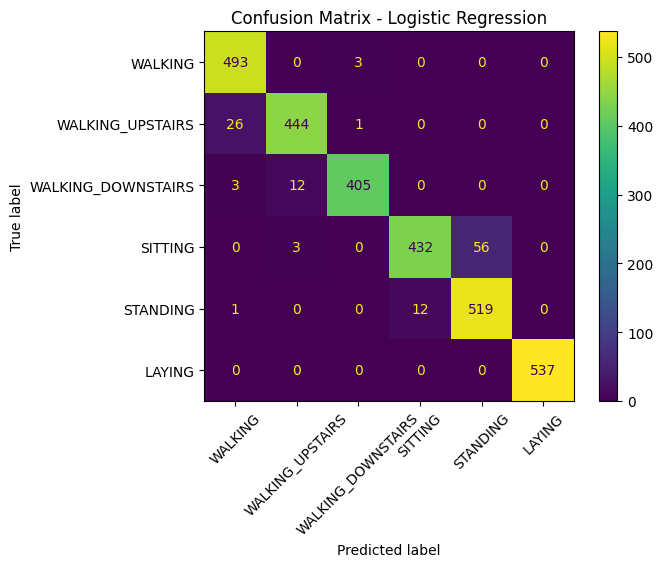

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test.values.ravel(),
    y_pred,
    display_labels=activity_labels["activity"],
    xticks_rotation=45
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [21]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.values.ravel(),
        y_pred,
        target_names=activity_labels["activity"]
    )
)

                    precision    recall  f1-score   support

           WALKING       0.94      0.99      0.97       496
  WALKING_UPSTAIRS       0.97      0.94      0.95       471
WALKING_DOWNSTAIRS       0.99      0.96      0.98       420
           SITTING       0.97      0.88      0.92       491
          STANDING       0.90      0.98      0.94       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



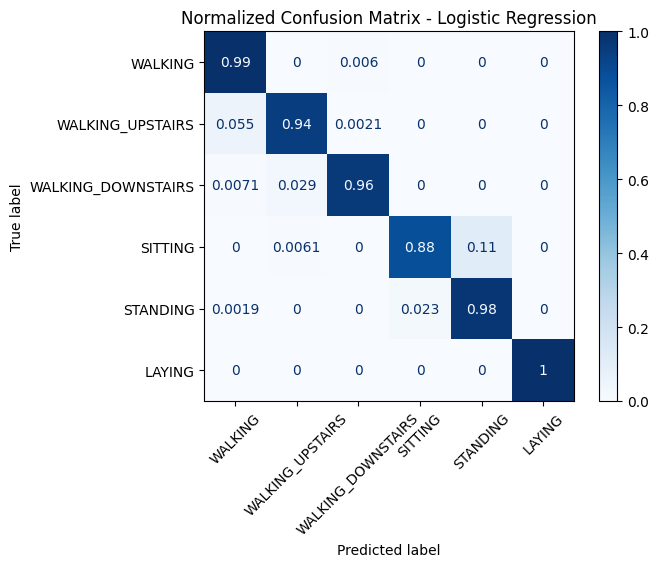

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test.values.ravel(),
    y_pred,
    display_labels=activity_labels["activity"],
    normalize="true",
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Normalized Confusion Matrix - Logistic Regression")
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train, y_train.values.ravel())

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test.values.ravel(),
    rf_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.9256871394638616
